<a href="https://colab.research.google.com/github/GaborVxxx/ml_notes/blob/main/POS_tagging(part_of_speach).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import nltk
from nltk.corpus import brown

In [49]:
nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

In [50]:
corpus = brown.tagged_sents(tagset='universal')
print(corpus)
print(len(corpus))

[[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')], [('The', 'DET'), ('jury', 'NOUN'), ('further', 'ADV'), ('said', 'VERB'), ('in', 'ADP'), ('term-end', 'NOUN'), ('presentments', 'NOUN'), ('that', 'ADP'), ('the', 'DET'), ('City', 'NOUN'), ('Executive', 'ADJ'), ('Committee', 'NOUN'), (',', '.'), ('which', 'DET'), ('had', 'VERB'), ('over-all', 'ADJ'), ('charge', 'NOUN'), ('of', 'ADP'), ('the', 'DET'), ('election', 'NOUN'), (',', '.'), ('``', '.'), ('deserves', 'VERB'), ('the', 'DET'), ('praise', 'NOUN'), ('and', 'CONJ'), ('thanks', 'NOUN'), ('of', 'ADP'), ('the', 'DET'), ('City

In [51]:
# split the words for its place, and keep it in the same order
inputs = []
targets = []

for sentence_tag_pairs in corpus:
  tokens = []
  target = []
  for token, tag in sentence_tag_pairs:
    tokens.append(token)
    target.append(tag)
  inputs.append(token)
  targets.append(target)

print(len(inputs))
print(len(targets))

57340
57340


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, Bidirectional, LSTM, GRU, SimpleRNN, Embedding, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [53]:
# split the data and the lables
train_inputs, test_inputs, train_targets, test_targets = train_test_split(inputs, targets, test_size=0.2)
print(len(train_inputs))
print(len(test_inputs))
print(len(train_targets))
print(len(test_targets))

45872
11468
45872
11468


In [54]:
# Convert sentences to sequences

MAX_VOCAB_SIZE = None

# capitalization might be useful BUT need testing
should_lowercase = False
word_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    lower=should_lowercase,
    oov_token='UNK' # we need to keep unknown words in place, to make sure the tagse are aligne with tha data correctly
)

word_tokenizer.fit_on_texts(inputs) # use all text to map the words
train_inputs_int = word_tokenizer.texts_to_sequences(train_inputs)
test_inputs_int = word_tokenizer.texts_to_sequences(test_inputs)

In [55]:
# get word -> integer mapping
word2idx = word_tokenizer.word_index
V = len(word2idx)
print('Found %s unique tokens.' % V)

Found 929 unique tokens.


In [56]:
# flatten list of lists
def flatten(list_of_lists):
  return [item for sublist in list_of_lists for item in sublist]

In [57]:
# we work out the unique list of lables
all_train_targets = set(flatten(train_targets))
all_test_targets = set(flatten(test_targets))
print(all_train_targets)
print(all_test_targets)

{'PRON', 'NUM', 'X', 'NOUN', 'ADJ', '.', 'DET', 'ADV', 'CONJ', 'VERB', 'PRT', 'ADP'}
{'NUM', 'PRON', 'X', 'NOUN', 'ADJ', '.', 'DET', 'ADV', 'CONJ', 'VERB', 'PRT', 'ADP'}


In [58]:
all_train_targets == all_test_targets

True

In [59]:
# convert target to sequences
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(targets) # use all target
print(tag_tokenizer.word_index)
train_targets_int = tag_tokenizer.texts_to_sequences(train_targets)
test_targets_int = tag_tokenizer.texts_to_sequences(test_targets)

{'noun': 1, 'verb': 2, '.': 3, 'adp': 4, 'det': 5, 'adj': 6, 'adv': 7, 'pron': 8, 'conj': 9, 'prt': 10, 'num': 11, 'x': 12}


In [60]:
# save it for later use
train_targets_int_unpadded = train_targets_int
test_targets_int_unpadded = test_targets_int

In [61]:
# before padding, find max documnet length
# we don't want to truncate any inputs
# which would also truncate targets
maxlen_train = max([len(x) for x in train_inputs])
maxlen_test = max([len(x) for x in test_inputs])
print(maxlen_train)
print(maxlen_test)
T = max(maxlen_train, maxlen_test)
print(T)

20
15
20


In [62]:
# pad sequences so that we get a N x T maatrix
train_inputs_int = pad_sequences(train_inputs_int, maxlen=T)
test_inputs_int = pad_sequences(test_inputs_int, maxlen=T)
print(train_inputs_int.shape)
print(test_inputs_int.shape)

(45872, 20)
(11468, 20)


In [63]:

train_targets_int = pad_sequences(train_targets_int, maxlen=T)
test_targets_int = pad_sequences(test_targets_int, maxlen=T)
print(train_targets_int.shape)
print(test_targets_int.shape)

(45872, 20)
(11468, 20)


In [64]:
# number of classes
K = len(tag_tokenizer.word_index) + 1
print(K)

13


In [65]:
# create the model

# embedding dimensionality
D = 32

i = Input(shape=(T,))
x = Embedding(V + 1, D, mask_zero=True)(i) # ignore 0 values in matrix
x = Bidirectional(LSTM(32, return_sequences=True))(x) # this is run 2 version and work out the befor and after vector around the word before --> word <-- after
x = Dense(K)(x)

model = Model(i, x)

model.summary()

model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 20)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_6 (Embedding)   │ (None, 20, 32)         │         29,760 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal_6 (NotEqual)    │ (None, 20)             │              0 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_6           │ (None, 20, 64)         │         16,640 │ embedding_6[0][0],     │
│ (Bidirectional)           │                        │                │ not_equal_6[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 20, 13)         │            845 │ bidirectional_6[0][0]  │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 47,245 (184.55 KB)

 Trainable params: 47,245 (184.55 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
r = model.fit(
    train_inputs_int,
    train_targets_int,
    validation_data=(test_inputs_int, test_targets_int),
    epochs=5,
    batch_size=64
)

Epoch 1/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.1795 - loss: 1.5126 - val_accuracy: 0.1782 - val_loss: 0.6197
Epoch 2/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.1788 - loss: 0.5528 - val_accuracy: 0.1783 - val_loss: 0.5166
Epoch 3/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.1575 - loss: 0.3171 - val_accuracy: 0.1206 - val_loss: 0.4815
Epoch 4/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.1197 - loss: 0.2470 - val_accuracy: 0.1206 - val_loss: 0.5009
Epoch 5/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.1204 - loss: 0.1395 - val_accuracy: 0.1206 - val_loss: 0.5195


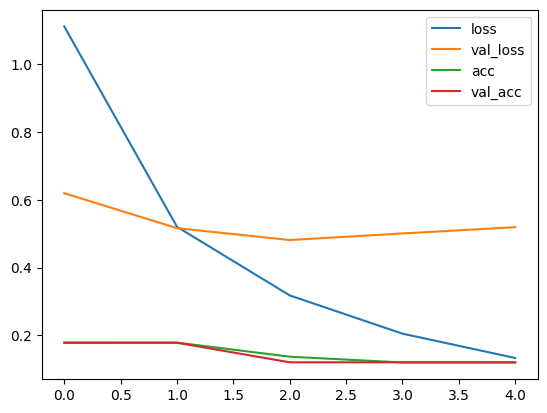

In [67]:
# plot loss / iter + acc
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()